<a href="https://colab.research.google.com/github/BenCheung1/Pytorch_Sandbox/blob/main/Pyt_IrisNN_EvalTestDataSet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import torch
## Tensor basics: https://docs.pytorch.org/docs/2.13/tensors.html
## Iris Database https://archive.ics.uci.edu/dataset/53/iris
## Output: Iris Setosa, Iris Versicolour, Iris Virginica
## Input Features: Sepal length, width, Petal Len/Wid
## Torch Neural Net library & Functional NN Library
import torch.nn as nn
import torch.nn.functional as F

## Create a Model Class that inherits the nn.Module
class IrisModel (nn.Module):
    ## Input Layer (4 features of flow)
    ## --> Hidden Layer1 (number of neurons)
    ## --> H2(n)
    ## --> Output (3 classes of iris flowers)
    def __init__(self, in_features=4, hdnlyr1=8, hdnlyr2 =9, out_features =3):
       super().__init__() #Instantiate nn.Module
       ## Fully Connected Hidden Neural Layer "fc"
       self.fc1 = nn.Linear(in_features, hdnlyr1)
       self.fc2 = nn.Linear(hdnlyr1, hdnlyr2)
       self.out = nn.Linear(hdnlyr2, out_features)

    def forward(self, x):
       ## Rectified Linear Unit (Relu)
       x = F.relu(self.fc1(x))
       x = F.relu(self.fc2(x))
       x = self.out(x)
       return x

## Random a manual Seed for randomization
torch.manual_seed (87)
## create an instance of the model
model = IrisModel ()


In [13]:
import pandas as pd
import matplotlib.pyplot as Plt
%matplotlib inline
url = 'https://gist.githubusercontent.com/Thanatoz-1/9e7fdfb8189f0cdf5d73a494e4a6392a/raw/aaecbd14aeaa468cd749528f291aa8a30c2ea09e/iris_dataset.csv'
mydataframe = pd.read_csv(url)
mydataframe
mydataframe.tail(5)
mydataframe.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [14]:
## Change the last column from (output) strings to numbers
mydataframe['target'] = mydataframe['target'].replace('Iris-setosa',0.0)
mydataframe['target'] = mydataframe['target'].replace('Iris-versicolor',1.0)
mydataframe['target'] = mydataframe['target'].replace('Iris-virginica',2.0)
mydataframe['target'] = mydataframe['target'].infer_objects(copy=False)

mydataframe.tail(70)

# Error: /tmp/ipykernel_1482/3051281745.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and
# will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`.
# To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_2695/4040046338.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mydataframe['target'] = mydataframe['target'].replace('Iris-virginica',2.0)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
80,5.5,2.4,3.8,1.1,1.0
81,5.5,2.4,3.7,1.0,1.0
82,5.8,2.7,3.9,1.2,1.0
83,6.0,2.7,5.1,1.6,1.0
84,5.4,3.0,4.5,1.5,1.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [5]:
# Train, Test, Split Set
# Set X = features (so drop the target column); and y = outcomes
# convention uppercase X, lowercase y
X = mydataframe.drop('target', axis=1)
y = mydataframe['target']
# Convert these to numpy Arrays
X = X.values
y = y.values
y

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [15]:
# Import Train, Test & Split from Sidekit Learn
from sklearn.model_selection import train_test_split
# Train Test Split (use 80% as "main" data, 20% as test)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state =87)

# Convert X features to float tensor
X_train= torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

# Convert y labels to tensors long
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

y_train

tensor([0, 1, 0, 2, 1, 1, 0, 2, 1, 2, 2, 1, 2, 1, 2, 1, 0, 0, 2, 0, 1, 1, 2, 0,
        1, 1, 0, 2, 2, 1, 2, 2, 1, 0, 1, 1, 0, 1, 2, 2, 2, 1, 0, 2, 0, 2, 0, 0,
        1, 1, 0, 2, 0, 0, 2, 1, 2, 2, 1, 1, 1, 0, 2, 0, 0, 1, 0, 1, 1, 1, 2, 2,
        0, 2, 2, 0, 0, 2, 0, 0, 0, 1, 2, 0, 2, 0, 2, 1, 1, 0, 0, 2, 2, 2, 1, 1,
        2, 0, 2, 2, 1, 2, 2, 1, 2, 1, 1, 0, 0, 0, 2, 1, 1, 0, 1, 1, 2, 0, 2, 1])

In [16]:
# Set the Criterion of model to measure the error, how far the predictions are from the data.
criterion = nn.CrossEntropyLoss()
# Choose Adam Optimizer
# learning rate (lr) = (if error doesn't go down after iteractions epochs lower our learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# the lower the learning rate the longer the training time

In [17]:
model.parameters

<bound method Module.parameters of IrisModel(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

In [19]:
# Train the Model
# Number of Epochs (one run through)
epoch = 100
# Keep track of errors, losses, python list
losses = []
for i in range(epoch):
  # Go forward and get a prediction
  y_pred = model.forward(X_train) #get predicted results
  # Measure the loss/error, will be high at first
  loss = criterion(y_pred, y_train) #predicted value vs y_train value
  # Keep track of our losses
  losses.append(loss.detach().numpy())
  # Print every 10 epochs
  if i % 10 == 0:
    print(f'Epoch: {i} and loss: {loss}')
  # Do some back propagation:
  # take the error rate of forward propagation feed it back
  # through the network to fine tune the weights.
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


Epoch: 0 and loss: 0.2271062582731247
Epoch: 10 and loss: 0.15050937235355377
Epoch: 20 and loss: 0.10536763817071915
Epoch: 30 and loss: 0.07989642024040222
Epoch: 40 and loss: 0.06568585336208344
Epoch: 50 and loss: 0.05698498338460922
Epoch: 60 and loss: 0.05115489289164543
Epoch: 70 and loss: 0.046938829123973846
Epoch: 80 and loss: 0.04368792474269867
Epoch: 90 and loss: 0.041056565940380096


Text(0.5, 0, 'Epoch')

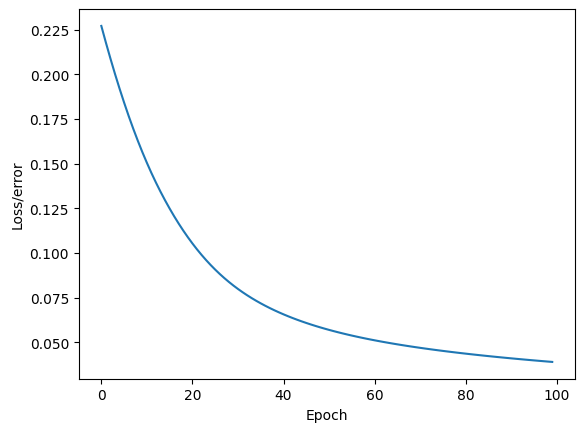

In [21]:
# Plot it out
Plt.plot(range(epoch), losses)
Plt.ylabel("Loss/error")
Plt.xlabel("Epoch")

In [28]:
# Evaluate Model on Test Data Set (validate model on test set)
with torch.no_grad():  # turn off back propagation
  y_eval = model.forward(X_test) # X_test are features from our test set,
  # y_eval will be predictions
  loss = criterion (y_eval, y_test) #find the loss/error
correct = 0
with torch.no_grad():
  for i, data in enumerate (X_test):
    y_val = model.forward(data)

    if y_test[i] == 0:
      rslt = "Setosa"
    elif y_test[i] == 1:
      rslt = 'Versicolor'
    else:
      rslt = 'Virginica'
    # Will tell us what type of iris the NN thinks it is
    print (f'{i+1}.) {str(y_val)} \t {rslt} \t {y_val.argmax().item()}')
    # the Highest number in the Tensor is what the NN thinks it is.
    # e.g. w/ 1. tensor 13.3, 7.22, -15.97 it is a type=0
    # Correct or Not
    if y_val.argmax().item() == y_test[i]:
      correct += 1
print (f'We got {correct} correct')

1.) tensor([ 13.3280,   7.2228, -15.9780]) 	 Setosa 	 0
2.) tensor([-11.9231,   4.2012,  10.9969]) 	 Virginica 	 2
3.) tensor([-10.3800,   3.8594,   9.5117]) 	 Virginica 	 2
4.) tensor([-15.0612,   3.5586,  14.6057]) 	 Virginica 	 2
5.) tensor([-13.6401,   2.8907,  13.3662]) 	 Virginica 	 2
6.) tensor([-0.6359,  7.1608, -2.2592]) 	 Versicolor 	 1
7.) tensor([ 12.0427,   6.5779, -14.4405]) 	 Setosa 	 0
8.) tensor([-3.2476,  5.8375,  1.1366]) 	 Versicolor 	 1
9.) tensor([-3.6400,  5.5547,  1.6434]) 	 Versicolor 	 1
10.) tensor([-3.2336,  5.9126,  1.0311]) 	 Versicolor 	 1
11.) tensor([ 14.5622,   7.9895, -17.4718]) 	 Setosa 	 0
12.) tensor([ 13.7764,   7.3142, -16.4984]) 	 Setosa 	 0
13.) tensor([ 12.3525,   7.0136, -14.8445]) 	 Setosa 	 0
14.) tensor([-8.1871,  4.2904,  7.0312]) 	 Versicolor 	 2
15.) tensor([ 14.8119,   7.7766, -17.7302]) 	 Setosa 	 0
16.) tensor([ 12.6325,   6.8829, -15.1470]) 	 Setosa 	 0
17.) tensor([ 14.6754,   7.7252, -17.5689]) 	 Setosa 	 0
18.) tensor([ 1.0120,  